In [487]:

import numpy as np
import pandas as pd
from tensorflow.keras.models import Model,Sequential
from tensorflow.keras.layers import Dense,SimpleRNN,Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


In [488]:
data=pd.read_csv('Stock Analysis/CSCO_2006-01-01_to_2018-01-01.csv')
data.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,17.21,17.49,17.18,17.45,55432166,CSCO
1,2006-01-04,17.48,17.93,17.46,17.85,80409776,CSCO
2,2006-01-05,17.94,18.48,17.93,18.35,118588943,CSCO
3,2006-01-06,18.51,18.88,18.47,18.77,122450979,CSCO
4,2006-01-09,18.97,19.11,18.92,19.06,78604868,CSCO


In [489]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3019 entries, 0 to 3018
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3019 non-null   object 
 1   Open    3019 non-null   float64
 2   High    3019 non-null   float64
 3   Low     3019 non-null   float64
 4   Close   3019 non-null   float64
 5   Volume  3019 non-null   int64  
 6   Name    3019 non-null   object 
dtypes: float64(4), int64(1), object(2)
memory usage: 165.2+ KB


In [490]:
data.describe()

,Open,High,Low,Close,Volume
count,3019.000000,3019.000000,3019.000000,3019.000000,3.019000e+03
mean,24.031736,24.277714,23.793014,24.039632,4.440027e+07
std,5.031488,5.031514,5.035515,5.034167,2.875882e+07
min,13.930000,14.120000,11.780000,13.620000,6.155794e+06
25%,20.070000,20.270000,19.885000,20.105000,2.700610e+07
50%,23.840000,24.080000,23.600000,23.890000,3.974033e+07
75%,27.580000,27.805000,27.350000,27.545000,5.464026e+07
max,38.880000,39.000000,38.490000,38.740000,5.600389e+08


In [491]:
data=data[['Open']]
data.head()

,Open
0,17.21
1,17.48
2,17.94
3,18.51
4,18.97


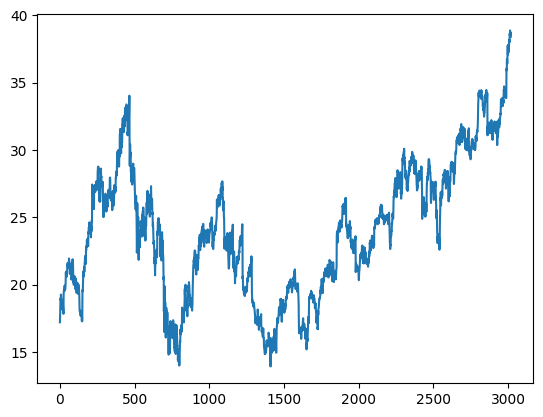

In [492]:
plt .plot(data[['Open']])

In [493]:
x=data['Open'].values
x

array([17.21, 17.48, 17.94, ..., 38.54, 38.73, 38.41], shape=(3019,))

In [494]:
split = 2500
x_train, x_test = x[:split], x[split:]

In [495]:
model=Sequential()
model.add(SimpleRNN(units=64,activation='tanh'))
model.add(Dense(1))

In [496]:
x[:10]

array([17.21, 17.48, 17.94, 18.51, 18.97, 18.87, 18.98, 19.27, 19.13,
       18.7 ])

In [497]:
model.compile(loss='mean_squared_error',optimizer='adam')

In [498]:
x_trainn,y_trainn=[],[]
for i in range(len(x_train)-15):
    d=i+15
    x_trainn.append(x_train[i:d,])
    y_trainn.append(x_train[d])

In [499]:
x_testt,y_testt=[],[]
for i in range(len(x_test)-15):
    d=i+15
    x_testt.append(x_test[i:d,])
    y_testt.append(x_test[d])

In [500]:
import numpy as np
x_trainn=np.array(x_trainn)
x_testt=np.array(x_testt)

In [501]:
x_testt.shape

(504, 15)

In [502]:
x_testt[1]

array([26.74, 26.49, 26.3 , 26.72, 27.  , 27.28, 26.6 , 26.58, 26.85,
       27.04, 27.41, 27.3 , 27.44, 27.66, 27.38])

In [503]:
y_testt[1]

np.float64(26.39)

In [504]:
x_trainn=np.reshape(x_trainn,(x_trainn.shape[0],x_trainn.shape[1],1))
x_testt=np.reshape(x_testt,(x_testt.shape[0],x_testt.shape[1],1))


In [505]:
x_trainn.shape

(2485, 15, 1)

In [506]:
x_trainn[1]

array([[17.48],
       [17.94],
       [18.51],
       [18.97],
       [18.87],
       [18.98],
       [19.27],
       [19.13],
       [18.7 ],
       [18.4 ],
       [18.85],
       [18.91],
       [18.54],
       [18.17],
       [18.35]])

In [507]:
y_trainn=np.array(y_trainn)
y_testt=np.array(y_testt)

In [508]:
early_stop=EarlyStopping(monitor='loss',patience=5,restore_best_weights=True)

In [509]:
history=model.fit(x_trainn,y_trainn,epochs=100,batch_size=20,callbacks=[early_stop])

Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 231.7255
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 53.5224
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 23.0959
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 10.0853
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 5.0009
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 2.9014
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.8667
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 1.3067
Epoch 9/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.9816
Epoch 10/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.7834
Epoch 11/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.6545
Epoch 12/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.5593
Epoch 13/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4920
Epoch 14/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4389
Epoch 15/100
125/125 ━━━━━━━━━━━━━━━━━

In [510]:
model.evaluate(x_testt,y_testt)

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.2548  


2.2547566890716553

In [513]:
XTpredic=model.predict(x_trainn)
xtpredic=model.predict(x_testt)
xfinal=np.concatenate([XTpredic,xtpredic],axis=0)

78/78 ━━━━━━━━━━━━━━━━━━━━ 0s 867us/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


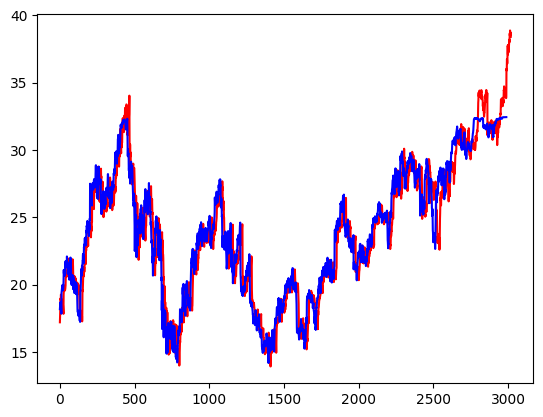

In [514]:
plt.plot(x,color='red')
plt.plot(xfinal,color='blue')